## Задание 1
*Используйте набор данных "Iris" из sklearn.datasets. 
Примените метод RFE с использованием модели логистической регрессии.
Укажите количество признаков для выбора и сравните производительность модели с и без этих
признаков.*

In [27]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

### Загружаем Датасет

In [28]:
loaded_data = load_iris()
df = pd.DataFrame(loaded_data.data, columns=loaded_data.feature_names)
df["target"] = loaded_data.target

In [29]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [30]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


#### Матрица Корреляции позволяет нам оценить влияние признаков друг на друга. 
#### Как видим, в данном случае имеется множество коррелирующих признаков.

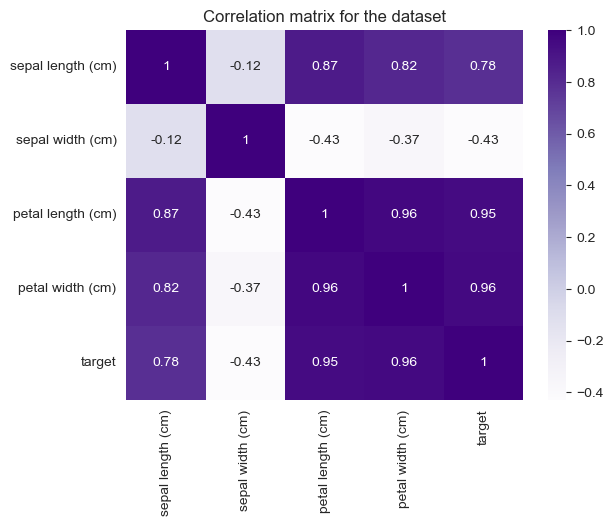

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True, cmap="Purples")
plt.title("Correlation matrix for the dataset")
plt.show()

### Разделяем данные на тренировочную и тестовую выборки

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(["target"], axis=1),
    df["target"],
    test_size=0.4,
    shuffle=True,
    random_state=42
)

## **Стандартизация Данных**
#### Стандартизация позволяет нам более эффективно использовать модель Логистической Регрессии, которую мы будем применять в этом задании
### **_Зачем нужна стандартизация?_**
* Устранить масштабные различия между признаками, если те использую разные шкалы
* Ускорение сходимости алгоритмов, использующих градиентный спуск (например, Логистическую Регрессию)
* Предотвращение "доминирования" одного признака над другим
#### Для стандартизации будем использовать *StandardScaler* из sklearn, преобразующий данные так, чтобы те имели нулевое среднее значение и единичную дисперсию (стандартное отклонение)

https://scikit-learn.org/0.24/modules/generated/sklearn.preprocessing.StandardScaler.html

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Создаём и обучаем модель Логистической Регресии со всеми признаками

In [34]:
base_model = LogisticRegression(max_iter=500)
base_model.fit(X_train_scaled, y_train)
y_pred_base = base_model.predict(X_test_scaled)

### **RFE | Recursive Feature Elimination**
#### Отбор признаков является важной задачей в машинном обучении. Оптимальное количество признаков может как увеличить точность модели (в случае с большим их количеством, когда есть совершенно не влияющие, или плохо влияющие на результат признаки), так и ускорить обучение, не сильно потеряв в точности
#### **RFE** это один из способов отбора признаков. Он рекурсивно удаляет наименее важные признаки, основываясь на весах модели. Работает следующим образом:
1. **Обучение модели**: Модель обучается на всех доступных признаках.
2. **Оценка важности признаков**: На основе коэффициентов или важности признаков (например, весов в линейной регрессии или коэффициентов в деревьях решений) определяется значимость каждого признака.
3. **Удаление наименее важных признаков**: Наименее важные признаки удаляются.
4. **Рекурсия**: Процесс повторяется с оставшимися признаками до тех пор, пока не останется заданное количество признаков.

https://habr.com/ru/companies/otus/articles/528676/

https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html

In [35]:
from sklearn.feature_selection import RFE
rfe = RFE(estimator=LogisticRegression(max_iter=500), n_features_to_select=2)
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe.transform(X_test_scaled)

In [36]:
print(f"Отобранные признаки: {df.columns[rfe.get_support(indices=True)].tolist()}")

Отобранные признаки: ['petal length (cm)', 'petal width (cm)']


### Создаём и обучаем модель Логистической Регресии с признаками, отобранными RFE

In [37]:
model_rfe = LogisticRegression(max_iter=500)
model_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = model_rfe.predict(X_test_rfe)

### Применяем удобный classification_report для результатов на тестовой выборке от обеих моделей

In [38]:
print("Оценка результатов работы базовой модели:\n", classification_report(y_test, y_pred_base))

Оценка результатов работы базовой модели:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.95      1.00      0.97        19
           2       1.00      0.94      0.97        18

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



In [41]:
print("Оценка результатов работы модели с RFE:\n", classification_report(y_test, y_pred_rfe))

Оценка результатов работы модели с RFE:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.95      1.00      0.97        19
           2       1.00      0.94      0.97        18

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



### **Итог**:
#### Как мы видим даже по базовой метрике accuracy, предоставленной нам, в данном случае точность модели не упала даже после устранения двух из четырёх признаков. Происходит так вероятно потому что все признаки в данном датасете сильно коррелируют друг с другом. Таким образом, нам удалось избавиться от половины признаков, в принципе не потеряв в производительности модели.